## PREPROCESS MOVIE DATA ANALYZER DATASET

### STEP 1: LOAD DATASET

In [ ]:
import numpy as np 
import pandas as pd 

In [3]:
df_movies = pd.read_csv(r"C:\Abhishree\Projects_GitHubLinked\datasets\Movie Dataset\movie_data.csv")

df_top = pd.read_csv(r"C:\Abhishree\Projects_GitHubLinked\datasets\Movie Dataset\Top_rated_movies (1).csv")


#### STEP 1a: SEE WHAT DOES THE DATASET CONTAINS. (INSPECT DATASET) 

In [4]:
df_movies

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275
...,...,...,...,...,...,...,...,...
1995,36955,True Lies,en,"A fearless, globe-trotting, terrorist-battling...",1994-07-15,True Lies,7.096,4575
1996,36669,Die Another Day,en,James Bond is sent to investigate the connecti...,2002-11-17,Die Another Day,5.998,3885
1997,1270125,Monster on a Plane,en,An exotic animal turns into a monster and beco...,2024-11-07,Monster on a Plane,4.778,45
1998,395000,Young Mother 4,ko,"Woo-jin, who is a repeater of college entrance...",2016-04-28,젊은 엄마 4,4.500,12


In [5]:
df_top

,id,title,original_language,original_title,overview,release_date,popularity,vote_count,rating
0,13448,Angels & Demons,en,Angels & Demons,Harvard symbologist Robert Langdon is recruite...,2009-04-20,6.8861,7323,6.719
1,9603,Clueless,en,Clueless,"Shallow, rich and socially successful Cher is ...",1995-07-19,7.5190,4801,7.255
2,6557,27 Dresses,en,27 Dresses,Altruistic Jane finds herself facing her worst...,2008-01-10,5.7786,3421,6.453
3,1333100,Attack on Titan: THE LAST ATTACK,ja,劇場版「進撃の巨人」完結編 THE LAST ATTACK,A colossal-sized omnibus film bringing togethe...,2024-03-20,6.0979,205,8.700
4,578701,Those Who Wish Me Dead,en,Those Who Wish Me Dead,A young boy finds himself pursued by two assas...,2021-05-05,6.2045,1849,6.607
...,...,...,...,...,...,...,...,...,...
9995,1401586,Sonic the Hedgehog 4,en,Sonic the Hedgehog 4,"Sonic the Hedgehog, joined by a new hero named...",2027-03-11,7.2231,0,0.000
9996,76203,12 Years a Slave,en,12 Years a Slave,"In the pre-Civil War United States, Solomon No...",2013-10-18,6.4827,11993,7.931
9997,516486,Greyhound,en,Greyhound,A first-time captain leads a convoy of allied ...,2020-07-09,7.0485,3313,7.417
9998,1137350,The Phoenician Scheme,en,The Phoenician Scheme,Wealthy businessman Zsa-zsa Korda appoints his...,2025-05-23,6.0546,918,6.500


#### STEP 2: CHECK DUPLICATES
Check which IDs from df_movies exist in df_top.

In [6]:
duplicate_ids_count = df_movies['id'].isin(df_top['id']).sum()
# count how many rows
duplicate_ids_count

np.int64(13)

#### STEP 2a : Check for duplicate rows in the same DataFrame.

In [7]:
df_movies['id'].duplicated().sum()

np.int64(9)

In [8]:
df_top['id'].duplicated().sum()

np.int64(9980)

> Shocking output with df_top['id'].duplicated().sum() as duplicates = 9,980 and total file contains 10,000 rows.

> duplicate_ids_count = df_movies['id'].isin(df_top['id']).sum()
it shows 13 are duplicates. which means out of those 20 in df_top 13 already exists in df_movies. only 7 are unique. 

#### STEP 3: DROPPING DUPLICATE VALUES.

In [9]:
df_top_clean = df_top.drop_duplicates(subset=['id']) 


In [10]:
# Checking the new shape: 
df_top_clean.shape

(20, 9)

In [11]:
df_movies_clean = df_movies.drop_duplicates(subset= ['id']) 


In [12]:
df_movies_clean.shape

(1991, 8)

>in df_top_clean has 20 rows out of which 13 exist in df_movies_clean. Merging them both would simply add the popularity column for those 13. And df_movies_clean has 1991 rows, merging them with those 13 seems useless

### STEP 4: HANDLING MISSING VALUES

In [13]:
df_movies_clean.isnull().sum()

id                    0
title                 0
original_language     0
overview             15
release_date          4
original_title        0
vote_average          0
vote_count            0
dtype: int64

In [14]:
df_movies_clean.dtypes

id                     int64
title                    str
original_language        str
overview                 str
release_date             str
original_title           str
vote_average         float64
vote_count             int64
dtype: object

> release_date is stored as string data type which is a problem. so we need to store it as numbers.


> We use .to_datetime() to convert that string into data and time.  


In [15]:
df_movies_clean['release_date'] = pd.to_datetime(df_movies_clean['release_date']) 

In [16]:
df_movies_clean.dtypes

id                            int64
title                           str
original_language               str
overview                        str
release_date         datetime64[us]
original_title                  str
vote_average                float64
vote_count                    int64
dtype: object

> Now handling the missing values.

In [17]:
df_movies_clean = df_movies_clean.dropna(subset=['release_date']) 

> Here we are dropping those 4 rows as in 2000 dataset 4 wont make any change. 

In [18]:
df_movies_clean.isnull().sum()

id                    0
title                 0
original_language     0
overview             14
release_date          0
original_title        0
vote_average          0
vote_count            0
dtype: int64

> Now we have to fix the missing overview. Instead of dropping we could fill it with a message such as overview not available. 

In [19]:
df_movies_clean['overview'] = df_movies_clean['overview'].fillna("no overview available")

In [20]:
df_movies_clean.isnull().sum()

id                   0
title                0
original_language    0
overview             0
release_date         0
original_title       0
vote_average         0
vote_count           0
dtype: int64

In [21]:
df_movies_clean.head()

,id,title,original_language,overview,release_date,original_title,vote_average,vote_count
0,1339713,Obsession,en,"After breaking the mysterious ""One Wish Willow...",2026-05-13,Obsession,7.900,497
1,1304313,Lee Cronin's The Mummy,en,The young daughter of a journalist disappears ...,2026-04-15,Lee Cronin's The Mummy,8.056,1548
2,1433117,Kara,ta,"A thief tries to go straight, but when predato...",2026-04-30,கர,5.800,14
3,1380291,Tom Clancy's Jack Ryan: Ghost War,en,Jack Ryan is reluctantly pulled back into espi...,2026-05-20,Tom Clancy's Jack Ryan: Ghost War,7.105,457
4,1083381,Backrooms,en,A strange doorway appears in the basement of a...,2026-05-27,Backrooms,6.700,275


#### The dataset had titles in the original language other than english. 


In [22]:
df_movies_clean['original_language'].value_counts().head(10)

original_language
en    1462
ja      79
ko      69
zh      50
fr      45
es      42
hi      37
it      30
tl      27
cn      25
Name: count, dtype: int64

> Let's generate a visual to see this data for fun..

C:\Users\abhis\AppData\Local\Temp\ipykernel_25692\3478181573.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_language.index, y=top_language.values, palette='viridis',legend=False)


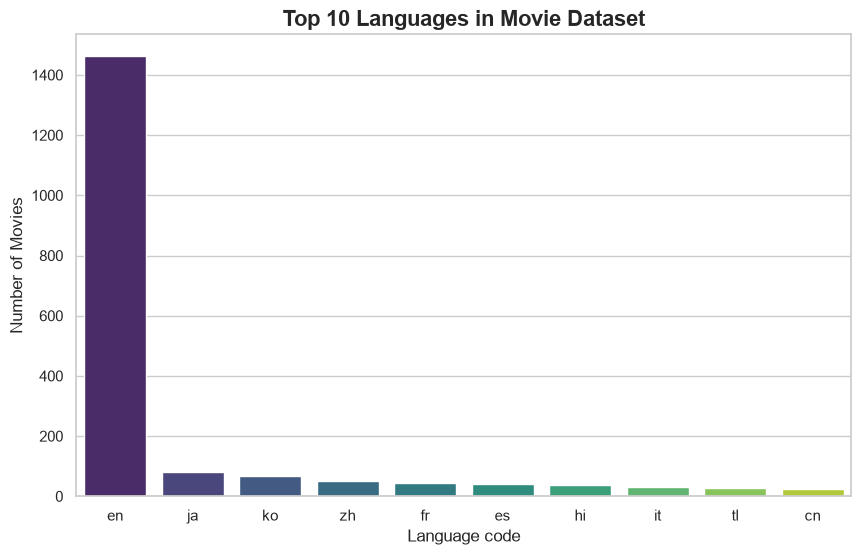

In [23]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme(style= "whitegrid")
top_language = df_movies_clean['original_language'].value_counts().head(10) 
plt.figure(figsize=(10,6))
sns.barplot(x=top_language.index, y=top_language.values, palette='viridis',legend=False)

plt.title("Top 10 Languages in Movie Dataset", fontsize=16,fontweight='bold')
plt.xlabel("Language code",fontsize=12)
plt.ylabel("Number of Movies", fontsize=12) 

plt.show()


> Now we move onto see ratings. If there are any outliers. 

Text(0, 0.5, 'frequency')

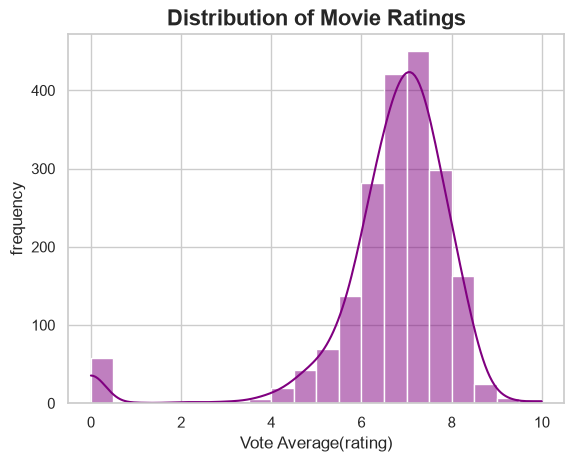

In [24]:
plt.Figure(figsize=(10,6)) 
sns.histplot(df_movies_clean['vote_average'], kde=True, color='purple',bins=20) 

plt.title("Distribution of Movie Ratings", fontsize=16, fontweight='bold') 
plt.xlabel("Vote Average(rating)",fontsize=12)
plt.ylabel("frequency",fontsize=12)

> the above image shows a spike at 0 rating, this could cause a problem for future models. So let's inspect that. 


In [35]:
zero_ratings = df_movies_clean[df_movies_clean['vote_average']==0] 

zero_ratings[['title','release_date','vote_average','vote_count']].head() 

,title,release_date,vote_average,vote_count
49,Deool Band 2,2026-05-21,0.0,0
58,Avatar Aang: The Last Airbender,2026-10-09,0.0,0
84,Toy Story 5,2026-06-17,0.0,0
116,The Furious,2026-06-10,0.0,0
123,Spider-Man: Brand New Day,2026-07-29,0.0,0


In [36]:
df_movies_clean['vote_average'].value_counts().head()

vote_average
0.0    58
7.0    26
7.3    25
6.5    17
7.4    16
Name: count, dtype: int64

> If you want to build a model later to predict movie success or analyze real audience behavior, keeping these 58 unrated movies will skew your results. You need to filter them out so you only work with movies that have actually been reviewed.

In [40]:
df_movies_clean = df_movies_clean[df_movies_clean['vote_count']>0]
df_movies_clean.shape

(1929, 8)